# Model Inference
## Loads best model from MLflow, preprocesses test data, generates submission
Loads the best model from the **MLflow Model Registry**, applies the identical preprocessing pipeline to `test.csv`, generates predictions, and writes a Kaggle submission CSV.

In [1]:
!pip install dagshub mlflow -q

import os
import numpy as np
import pandas as pd
import joblib
import mlflow
from mlflow.tracking import MlflowClient
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 443.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

## 1. Connect to MLflow / DagsHub

In [ ]:
DAGSHUB_USER  = "ekatsirekidze"
DAGSHUB_REPO  = "ML_HW1"
DAGSHUB_TOKEN = "your_token_here"

os.environ["MLFLOW_TRACKING_URI"]      = f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow"
os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USER
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

print("✅ Connected:", mlflow.get_tracking_uri())

✅ Connected: https://dagshub.com/ekatsirekidze/ML_HW1.mlflow


## 2. Load Best Model from MLflow

In [3]:
# Best model identified from MLflow experiments
# Run: ridge_a10_mi_top50 | CV RMSE: 0.13762
# Artifact run: abedb09ded6f4d049b1f83d576ea6ddb

client = MlflowClient()
client.download_artifacts("abedb09ded6f4d049b1f83d576ea6ddb", "model/best_model.pkl", ".")
model = joblib.load("/kaggle/working/best_model.pkl")
print(f"✅ Model loaded: {type(model)}")

✅ Model loaded: <class 'sklearn.linear_model._ridge.Ridge'>


In [4]:
train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
test_ids = test["Id"].copy()
print(f"Train: {train.shape}, Test: {test.shape}")

Train: (1460, 81), Test: (1459, 80)


## 3. Preprocess Test Data

Apply the exact same pipeline used on training data.

In [5]:
def preprocess(df, is_train=True, ohe=None, vt=None, mi_cols=None):
    df = df.copy()
    
    # Feature engineering
    df["HasFence"]    = df["Fence"].notna().astype(int)
    df["HouseAge"]    = df["YrSold"] - df["YearBuilt"]
    df["RemodAge"]    = df["YrSold"] - df["YearRemodAdd"]
    df["GarageAge"]   = df["YrSold"] - df["GarageYrBlt"]
    df["TotalBath"]   = df["FullBath"] + 0.5*df["HalfBath"] + df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"]
    df["TotalSF"]     = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalPorchSF"]= df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"] + df["WoodDeckSF"]
    
    # Drop columns
    drop_cols = ["Id", "Utilities", "Street", "PoolQC", "MiscFeature", "Alley", "Fence", "MiscVal"]
    year_cols = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold", "MoSold"]
    df = df.drop(columns=[c for c in drop_cols + year_cols if c in df.columns])
    
    # Fill NaN
    cat_cols = df.select_dtypes(include="object").columns.tolist()
    num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "SalePrice"]
    for col in cat_cols:
        df[col] = df[col].fillna("None")
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    
    # Ordinal encoding
    quality_map = {"None":0,"Po":1,"Fa":2,"TA":3,"Gd":4,"Ex":5}
    finish_map  = {"None":0,"Unf":1,"LwQ":2,"Rec":3,"BLQ":4,"ALQ":5,"GLQ":6}
    for col in ["ExterQual","ExterCond","BsmtQual","BsmtCond","HeatingQC",
                "KitchenQual","FireplaceQu","GarageQual","GarageCond"]:
        if col in df.columns:
            df[col] = df[col].map(quality_map)
    df["BsmtFinType1"] = df["BsmtFinType1"].map(finish_map)
    df["BsmtFinType2"] = df["BsmtFinType2"].map(finish_map)
    df["GarageFinish"] = df["GarageFinish"].map({"None":0,"Unf":1,"RFn":2,"Fin":3})
    df["BsmtExposure"] = df["BsmtExposure"].map({"None":0,"No":1,"Mn":2,"Av":3,"Gd":4})
    df["Functional"]   = df["Functional"].map({"Sal":0,"Sev":1,"Maj2":2,"Maj1":3,"Mod":4,"Min2":5,"Min1":6,"Typ":7})
    df["LandSlope"]    = df["LandSlope"].map({"Sev":0,"Mod":1,"Gtl":2})
    df["PavedDrive"]   = df["PavedDrive"].map({"N":0,"P":1,"Y":2})
    df["CentralAir"]   = df["CentralAir"].map({"N":0,"Y":1})
    df["MSSubClass"]   = df["MSSubClass"].astype(str)
    
    # OHE
    remaining_cat = df.select_dtypes(include="object").columns.tolist()
    if is_train:
        ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
        ohe_array = ohe.fit_transform(df[remaining_cat])
    else:
        ohe_array = ohe.transform(df[remaining_cat])
    ohe_cols = ohe.get_feature_names_out(remaining_cat)
    df_ohe   = pd.DataFrame(ohe_array, columns=ohe_cols, index=df.index)
    df = pd.concat([df.drop(columns=remaining_cat), df_ohe], axis=1)
    
    # Remove SalePrice if present
    if "SalePrice" in df.columns:
        df = df.drop(columns=["SalePrice"])
    
    # Variance threshold
    if is_train:
        vt = VarianceThreshold(threshold=0.01)
        X_vt = pd.DataFrame(vt.fit_transform(df), columns=df.columns[vt.get_support()], index=df.index)
    else:
        X_vt = pd.DataFrame(vt.transform(df), columns=df.columns[vt.get_support()], index=df.index)
    
    return X_vt, ohe, vt, mi_cols

## 4. Prepare Features

In [6]:
# Preprocess train
y = train["SalePrice"]
y_log = np.log1p(y)

X_train_vt, ohe, vt, _ = preprocess(train, is_train=True)

# Get MI top 50 features (same as experiment)
mi_scores = mutual_info_regression(X_train_vt, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_vt.columns).sort_values(ascending=False)
mi_cols = mi_series.head(50).index.tolist()

# Select and skew transform
def apply_skew_transform(X_df):
    X = X_df.copy()
    for col in X.select_dtypes(include=np.number).columns:
        if abs(X[col].skew()) > 0.75:
            X[col] = np.log1p(X[col].clip(lower=0))
    return X

X_train_mi = apply_skew_transform(X_train_vt[mi_cols])

# Preprocess test with same fitted transformers
X_test_vt, _, _, _ = preprocess(test, is_train=False, ohe=ohe, vt=vt)
X_test_mi = apply_skew_transform(X_test_vt.reindex(columns=mi_cols, fill_value=0))


print(f"X_train_mi: {X_train_mi.shape}")
print(f"X_test_mi:  {X_test_mi.shape}")

# Align to exact features and order the model was trained on
X_test_mi = X_test_mi.reindex(columns=model.feature_names_in_, fill_value=0)
print(f"X_test_mi aligned: {X_test_mi.shape}")

X_train_mi: (1460, 50)
X_test_mi:  (1459, 50)
X_test_mi aligned: (1459, 50)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 12, 13, 19] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## 5. Generate Predictions & Submission

In [7]:
# Predict using loaded model
log_preds  = model.predict(X_test_mi)
sale_preds = np.expm1(log_preds)

print(f"Min  : ${sale_preds.min():,.0f}")
print(f"Max  : ${sale_preds.max():,.0f}")
print(f"Mean : ${sale_preds.mean():,.0f}")

submission = pd.DataFrame({"Id": test_ids, "SalePrice": sale_preds})
submission.to_csv("submission.csv", index=False)
print(f"✅ Submission saved! Shape: {submission.shape}")
submission.head()

Min  : $46,545
Max  : $657,273
Mean : $171,400
✅ Submission saved! Shape: (1459, 2)


,Id,SalePrice
0,1461,113647.189682
1,1462,153408.815557
2,1463,175577.029912
3,1464,199414.904648
4,1465,186466.081510


## 6. Prediction Distribution

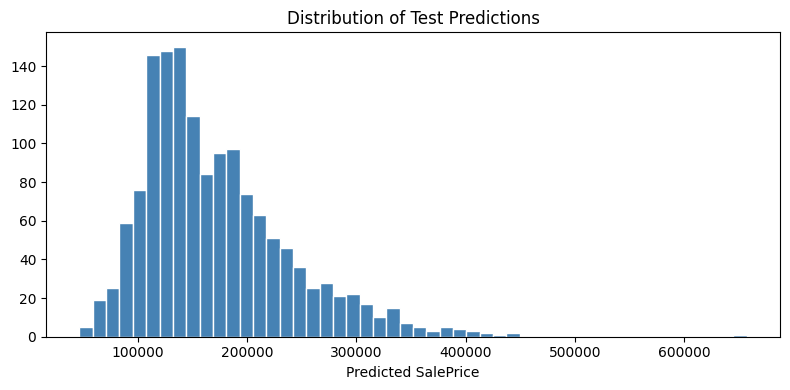

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(sale_preds, bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Predicted SalePrice")
plt.title("Distribution of Test Predictions")
plt.tight_layout()
plt.show()